In [1]:
!pip install fastapi uvicorn pyngrok pydantic pandas numpy scikit-learn xgboost matplotlib seaborn nest-asyncio joblib

In [2]:
import os
import joblib
import nest_asyncio
import threading
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

from fastapi import FastAPI
from pydantic import BaseModel
import uvicorn
from pyngrok import ngrok, conf

nest_asyncio.apply()
sns.set_theme(style="whitegrid")
print("Environment successfully initialized!")

Environment successfully initialized!


Dataset ingested successfully!
Total Records: 1338 | Total Features: 7

Null Check Profile:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


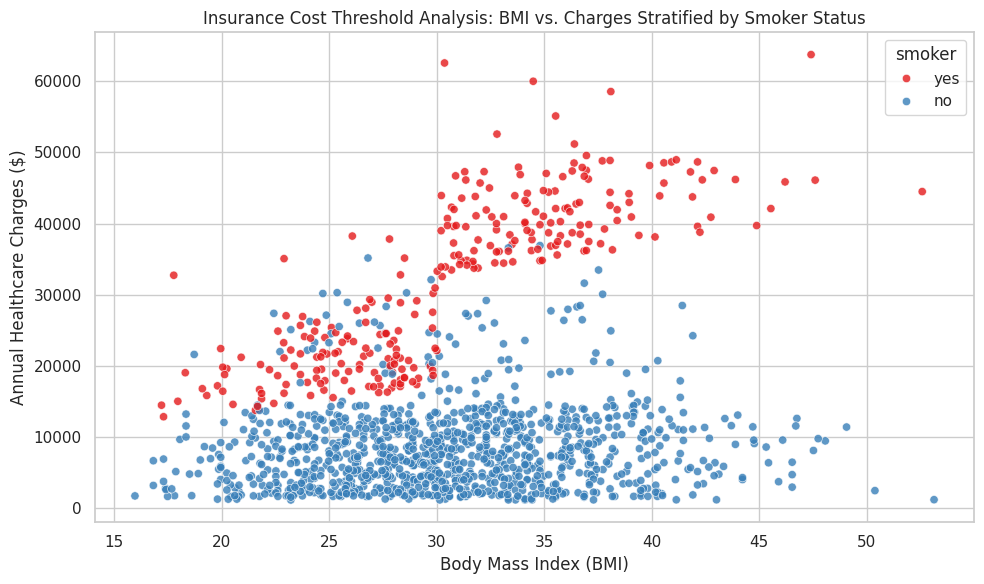


Exploratory chart successfully generated and saved as 'bmi_vs_charges_smoker.png'.


In [3]:
# Load the official medical insurance cost dataset layout
data_url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"

try:
    df = pd.read_csv(data_url)
    print("Dataset ingested successfully!")
    print(f"Total Records: {df.shape[0]} | Total Features: {df.shape[1]}\n")
except Exception as e:
    print(f"Error loading dataset: {e}")

print("Null Check Profile:")
print(df.isnull().sum())

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', palette='Set1', alpha=0.8)
plt.title('Insurance Cost Threshold Analysis: BMI vs. Charges Stratified by Smoker Status')
plt.xlabel('Body Mass Index (BMI)')
plt.ylabel('Annual Healthcare Charges ($)')
plt.tight_layout()
plt.savefig('bmi_vs_charges_smoker.png', dpi=300)
plt.show()
print("\nExploratory chart successfully generated and saved as 'bmi_vs_charges_smoker.png'.")

In [5]:
# Separate features and target
# Define categorical and numerical splits

X = df.drop(columns=['charges'])
y = df['charges']

num_cols = ['age', 'bmi', 'children']
cat_cols = ['sex', 'smoker', 'region']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ]
)

print(f"X_train Shape: {X_train.shape} | X_test Shape: {X_test.shape}")

X_train Shape: (1070, 6) | X_test Shape: (268, 6)


In [6]:
baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])
baseline_model.fit(X_train, y_train)
y_pred_base = baseline_model.predict(X_test)

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

#  Hyperparameter Tuning Space Setup
param_grid = {
    'regressor__n_estimators': [50, 100, 150],
    'regressor__max_depth': [4, 6, 8],
    'regressor__min_samples_split': [2, 5, 10]
}

print("Initiating cross-validated grid search...")
grid_search = GridSearchCV(rf_pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
y_pred_complex = best_model.predict(X_test)

print(f"\nOptimization Complete! Best Found Parameters:\n{grid_search.best_params_}")

Initiating cross-validated grid search...

Optimization Complete! Best Found Parameters:
{'regressor__max_depth': 4, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 50}


=== CAPSTONE EVALUATION PERFORMANCE MATRIX ===

[Baseline Linear Regression] Root Mean Squared Error: $5796.28
[Baseline Linear Regression] R-squared Score: 0.7836

[Tuned Random Forest Regressor] Root Mean Squared Error: $4477.72
[Tuned Random Forest Regressor] R-squared Score: 0.8709



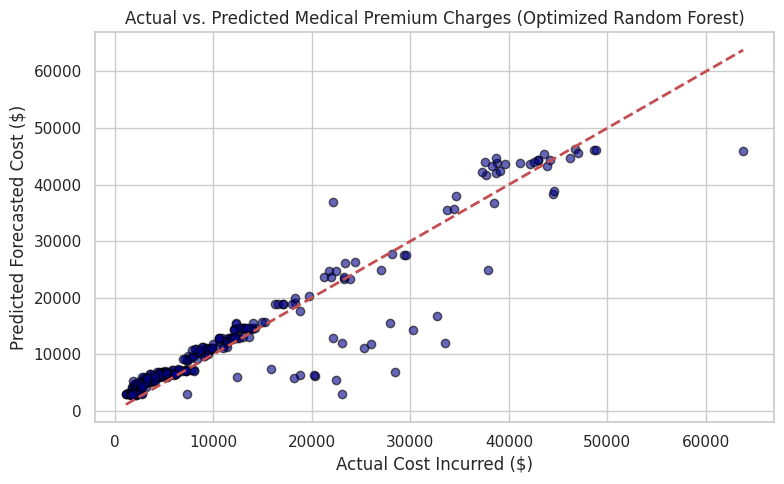

Winning prediction pipeline model successfully written to 'best_insurance_model.pkl'.


In [7]:
def print_metrics(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"[{label}] Root Mean Squared Error: ${rmse:.2f}")
    print(f"[{label}] R-squared Score: {r2:.4f}\n")
    return rmse, r2

print("=== CAPSTONE EVALUATION PERFORMANCE MATRIX ===\n")
base_rmse, base_r2 = print_metrics(y_test, y_pred_base, "Baseline Linear Regression")
comp_rmse, comp_r2 = print_metrics(y_test, y_pred_complex, "Tuned Random Forest Regressor")

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_complex, alpha=0.6, color='darkblue', edgecolors='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs. Predicted Medical Premium Charges (Optimized Random Forest)')
plt.xlabel('Actual Cost Incurred ($)')
plt.ylabel('Predicted Forecasted Cost ($)')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=300)
plt.show()

joblib.dump(best_model, 'best_insurance_model.pkl')
print("Winning prediction pipeline model successfully written to 'best_insurance_model.pkl'.")

In [8]:
#app.py
%%writefile app.py
from fastapi import FastAPI
from pydantic import BaseModel
import pandas as pd
import joblib

app = FastAPI(
    title="Medical Insurance Cost Forecaster API",
    description="Production-ready model endpoint generating custom annual health premium pricing models."
)

class CustomerProfile(BaseModel):
    age: int
    sex: str
    bmi: float
    children: int
    smoker: str
    region: str

model_pipeline = joblib.load('best_insurance_model.pkl')

@app.get("/")
def health_check():
    return {"status": "Operational", "engine": "RandomForestRegressor"}

@app.post("/predict")
def generate_forecast(profile: CustomerProfile):
    input_data = pd.DataFrame([{
        'age': profile.age,
        'sex': profile.sex,
        'bmi': profile.bmi,
        'children': profile.children,
        'smoker': profile.smoker,
        'region': profile.region
    }])

    raw_prediction = model_pipeline.predict(input_data)[0]

    return {
        "status": "Success",
        "predicted_annual_charges_usd": round(float(raw_prediction), 2)
    }

Writing app.py


In [9]:
# Paste  unique ngrok authtoken string here:
YOUR_NGROK_TOKEN = "3E2rS6JDRKty99ESncQZrGvoYUX_2Zn7aLWMB2jp8finqyZYc"

# Apply authtoken configuration profile
conf.get_default().auth_token = YOUR_NGROK_TOKEN

try:
    ngrok.disconnect(ngrok.connect(8000).public_url)
except:
    pass

public_url = ngrok.connect(8000).public_url
print("\n" + "="*60)
print(f"🚀 LIVE FASTAPI INSTANCE DETECTED ONLINE")
print(f"PUBLIC API URL: {public_url}")
print(f"INTERACTIVE API DOCUMENTATION PANEL URL: {public_url}/docs")
print("="*60 + "\n")

def run_api_server():
    uvicorn.run("app:app", host="127.0.0.1", port=8000, log_level="warning")

server_thread = threading.Thread(target=run_api_server, daemon=True)
server_thread.start()
print("Background engine thread actively streaming inbound requests.")


🚀 LIVE FASTAPI INSTANCE DETECTED ONLINE
PUBLIC API URL: https://childhood-subarctic-gift.ngrok-free.dev
INTERACTIVE API DOCUMENTATION PANEL URL: https://childhood-subarctic-gift.ngrok-free.dev/docs

Background engine thread actively streaming inbound requests.
